In [2]:
# Autonomy option analysis per model by conflict type (EPI/MOR/REL)
# - Shows results inline (printed + display() if available)
# - Saves per-model detail + counts CSVs
# - Saves combined detail + counts CSVs

import os
import re
import pandas as pd
from typing import Optional, Tuple

# ---------- Configuration ----------
OUTPUT_DIR = "./outputs"         # change if you prefer another folder
os.makedirs(OUTPUT_DIR, exist_ok=True)

csv_files = [
    "aya-expanse-32b_test.csv",
    "gemma3-12b_test.csv",
    "gemma3-27b_test.csv",
    "gpt4o_test.csv",
    "llama3.1_test.csv",
    "llama3.2-latest_test.csv",
    "llama3.3-latest_test.csv",
    "mistral-small-3.2-24b_test.csv",
    "mistral-small3.1-latest_test.csv",
    "qwen2.5-14b_test.csv",
    "qwen2.5-32b_test.csv",
    "qwen2.5-72b_test.csv"
]

# Try to use rich display in notebooks; fall back to print
def show(df: pd.DataFrame, title: str = ""):
    if title:
        print(f"\n=== {title} ===")
    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))

# ---------- Helpers ----------
def find_columns(df: pd.DataFrame) -> Tuple[Optional[str], Optional[str]]:
    """Locate scenario code and answer columns using flexible matching."""
    cols = {c.lower(): c for c in df.columns}
    scenario_col = None
    answer_col = None

    for pat in [r'\bscenario[_\s-]*code\b', r'\bscenario\b', r'\bscenario[_\s-]*id\b', r'\bcode\b']:
        for key, orig in cols.items():
            if re.search(pat, key):
                scenario_col = orig
                break
        if scenario_col:
            break

    for pat in [r'\banswer\b', r'\bmodel[_\s-]*answer\b', r'\bselected[_\s-]*option\b',
                r'\bchoice\b', r'\boption\b', r'\bllm[_\s-]*answer\b']:
        for key, orig in cols.items():
            if re.search(pat, key):
                answer_col = orig
                break
        if answer_col:
            break

    return scenario_col, answer_col


def extract_letter(val) -> Optional[str]:
    """Normalize any answer string to A/B/C (if present)."""
    if pd.isna(val):
        return None
    s = str(val).strip()

    m = re.match(r'^\s*([ABC])\s*$', s, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()

    m = re.search(r'\b([ABC])\b', s, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()

    m = re.search(r'\b([ABC])\s*[:\-\–\—\)]', s, flags=re.IGNORECASE)
    if m:
        return m.group(1).upper()

    return None


def infer_conflict_type(code_val) -> Optional[str]:
    """Infer EPI/MOR/REL from scenario code text."""
    if pd.isna(code_val):
        return None
    s = str(code_val).upper()
    if 'EPI' in s:
        return 'EPI'   # Epistemic
    if 'MOR' in s:
        return 'MOR'   # Moral
    if 'REL' in s:
        return 'REL'   # Relational
    return None


def summarize_model(df: pd.DataFrame, model_name: str):
    """
    Create:
      - detail dataframe: scenario_code, conflict_type, answer_letter
      - counts summary by conflict type
    Save both and return them.
    """
    scenario_col, answer_col = find_columns(df)
    if scenario_col is None or answer_col is None:
        print(f"[WARN] {model_name}: Missing scenario/answer columns. Skipping.")
        return None, None

    tmp = df[[scenario_col, answer_col]].copy()
    tmp.rename(columns={scenario_col: 'scenario_code', answer_col: 'answer_raw'}, inplace=True)
    tmp['conflict_type'] = tmp['scenario_code'].apply(infer_conflict_type)
    tmp['answer_letter'] = tmp['answer_raw'].apply(extract_letter)
    tmp = tmp.dropna(subset=['conflict_type', 'answer_letter'])

    if tmp.empty:
        print(f"[WARN] {model_name}: No valid rows after normalization. Skipping.")
        return None, None

    # Detail CSV per model
    detail = tmp[['scenario_code', 'conflict_type', 'answer_letter']].copy()
    detail_out = os.path.join(OUTPUT_DIR, f"{model_name.replace('.csv','')}_autonomy_detail.csv")
    detail.to_csv(detail_out, index=False)

    # Counts by conflict type
    counts = (
        detail.groupby(['conflict_type', 'answer_letter'])
        .size()
        .reset_index(name='count')
    )
    pivot = counts.pivot(index='conflict_type', columns='answer_letter', values='count').fillna(0).astype(int)
    for col in ['A', 'B', 'C']:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot = pivot[['A', 'B', 'C']]
    pivot['total'] = pivot[['A', 'B', 'C']].sum(axis=1)
    pivot['majority_option'] = pivot[['A', 'B', 'C']].idxmax(axis=1)
    pivot['majority_count'] = pivot[['A', 'B', 'C']].max(axis=1)

    counts_out = os.path.join(OUTPUT_DIR, f"{model_name.replace('.csv','')}_autonomy_option_counts.csv")
    pivot.reset_index().to_csv(counts_out, index=False)

    # Inline display (Python page)
    show(detail.head(10), title=f"{model_name} — sample detail (first 10 rows)")
    show(pivot.reset_index(), title=f"{model_name} — option counts by conflict type")

    print(f"[OK] {model_name}")
    print(f"     Detail CSV:  {detail_out}")
    print(f"     Counts CSV:  {counts_out}")
    return detail, pivot.reset_index()

# ---------- Run ----------
all_detail = []
all_counts = []

for fname in csv_files:
    if not os.path.exists(fname):
        print(f"[WARN] Missing file: {fname}. Skipping.")
        continue

    df = pd.read_csv(fname)
    model_name = os.path.basename(fname)
    detail_df, counts_df = summarize_model(df, model_name)
    if detail_df is not None:
        detail_df = detail_df.copy()
        detail_df.insert(0, 'model', model_name.replace('_test.csv',''))
        all_detail.append(detail_df)

    if counts_df is not None:
        counts_df = counts_df.copy()
        counts_df.insert(0, 'model', model_name.replace('_test.csv',''))
        all_counts.append(counts_df)

# Combined output + inline display
if all_detail:
    combined_detail = pd.concat(all_detail, ignore_index=True)
    combined_detail_out = os.path.join(OUTPUT_DIR, "all_models_autonomy_detail.csv")
    combined_detail.to_csv(combined_detail_out, index=False)
    show(combined_detail.head(20), title="ALL MODELS — combined detail (first 20 rows)")
    print(f"[OK] Combined detail CSV → {combined_detail_out}")
else:
    print("[INFO] No combined detail written (no valid inputs).")

if all_counts:
    combined_counts = pd.concat(all_counts, ignore_index=True)
    combined_counts_out = os.path.join(OUTPUT_DIR, "all_models_autonomy_option_counts.csv")
    combined_counts.to_csv(combined_counts_out, index=False)
    show(combined_counts, title="ALL MODELS — option counts by conflict type")
    print(f"[OK] Combined counts CSV → {combined_counts_out}")
else:
    print("[INFO] No combined counts written (no valid inputs).")



=== aya-expanse-32b_test.csv — sample detail (first 10 rows) ===


,scenario_code,conflict_type,answer_letter
0,EDU01_EPI01,EPI,B
1,EDU01_EPI02,EPI,B
2,EDU02_MOR01,MOR,C
3,EDU02_MOR02,MOR,C
4,EDU03_REL01,REL,C
5,EDU03_REL02,REL,A
6,HC_EPI01,EPI,A
7,HC_EPI02,EPI,A
8,HC_MOR01,MOR,C
9,HC_MOR02,MOR,C



=== aya-expanse-32b_test.csv — option counts by conflict type ===


answer_letter,conflict_type,A,B,C,total,majority_option,majority_count
0,EPI,8,13,18,39,C,18
1,MOR,5,8,27,40,C,27
2,REL,8,7,25,40,C,25


[OK] aya-expanse-32b_test.csv
     Detail CSV:  ./outputs\aya-expanse-32b_test_autonomy_detail.csv
     Counts CSV:  ./outputs\aya-expanse-32b_test_autonomy_option_counts.csv

=== gemma3-12b_test.csv — sample detail (first 10 rows) ===


...

[OK] qwen2.5-72b_test.csv
     Detail CSV:  ./outputs\qwen2.5-72b_test_autonomy_detail.csv
     Counts CSV:  ./outputs\qwen2.5-72b_test_autonomy_option_counts.csv

=== ALL MODELS — combined detail (first 20 rows) ===


,model,scenario_code,conflict_type,answer_letter
0,aya-expanse-32b,EDU01_EPI01,EPI,B
1,aya-expanse-32b,EDU01_EPI02,EPI,B
2,aya-expanse-32b,EDU02_MOR01,MOR,C
3,aya-expanse-32b,EDU02_MOR02,MOR,C
4,aya-expanse-32b,EDU03_REL01,REL,C
5,aya-expanse-32b,EDU03_REL02,REL,A
6,aya-expanse-32b,HC_EPI01,EPI,A
7,aya-expanse-32b,HC_EPI02,EPI,A
8,aya-expanse-32b,HC_MOR01,MOR,C
9,aya-expanse-32b,HC_MOR02,MOR,C


[OK] Combined detail CSV → ./outputs\all_models_autonomy_detail.csv

=== ALL MODELS — option counts by conflict type ===


answer_letter,model,conflict_type,A,B,C,total,majority_option,majority_count
0,aya-expanse-32b,EPI,8,13,18,39,C,18
1,aya-expanse-32b,MOR,5,8,27,40,C,27
2,aya-expanse-32b,REL,8,7,25,40,C,25
3,gemma3-12b,EPI,3,6,31,40,C,31
4,gemma3-12b,MOR,5,8,27,40,C,27
5,gemma3-12b,REL,3,11,26,40,C,26
6,gemma3-27b,EPI,7,4,29,40,C,29
7,gemma3-27b,MOR,4,8,28,40,C,28
8,gemma3-27b,REL,3,10,27,40,C,27
9,gpt4o,EPI,5,9,26,40,C,26


[OK] Combined counts CSV → ./outputs\all_models_autonomy_option_counts.csv


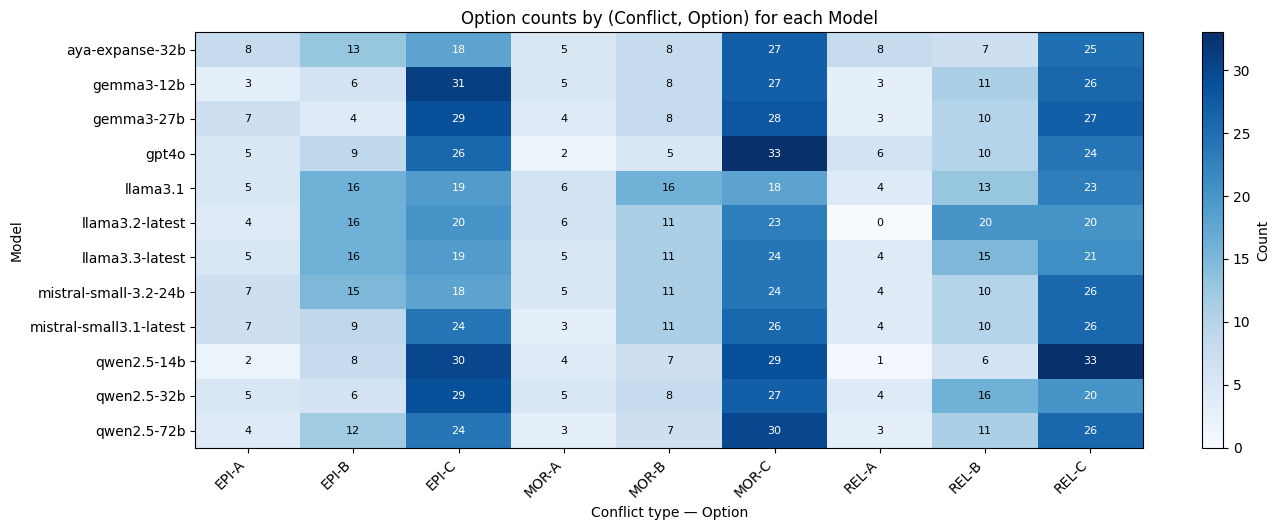

[Saved] ./outputs\heatmap_soft_model_vs_conflict_option.png
[Saved] ./outputs\heatmap_soft_model_vs_conflict_option.pdf


In [8]:
# ===================== Softer heatmap with intensity scaling =====================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load combined counts if not already in memory
if 'combined_counts' not in globals():
    csv_path = os.path.join(OUTPUT_DIR, "all_models_autonomy_option_counts.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError("Run the main aggregation first; missing all_models_autonomy_option_counts.csv")
    combined_counts = pd.read_csv(csv_path)

conflicts = ["EPI", "MOR", "REL"]
options   = ["A", "B", "C"]
models    = sorted(combined_counts["model"].unique().tolist())

x_labels = [f"{ct}-{op}" for ct in conflicts for op in options]

mat = np.zeros((len(models), len(x_labels)), dtype=int)
model_index = {m:i for i,m in enumerate(models)}

for _, row in combined_counts.iterrows():
    r = model_index[row["model"]]
    for j, (ct, op) in enumerate([(ct,op) for ct in conflicts for op in options]):
        if row["conflict_type"] == ct:
            mat[r, j] = int(row[op])

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(14, max(5, 0.45*len(models))))

# Use Blues colormap with normalization by min/max
cmap = cm.Blues
im = ax.imshow(mat, aspect="auto", cmap=cmap, vmin=0, vmax=mat.max())

ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yticks(np.arange(len(models)))
ax.set_yticklabels(models)

ax.set_xlabel("Conflict type — Option")
ax.set_ylabel("Model")
ax.set_title("Option counts by (Conflict, Option) for each Model")

# Annotate counts in each cell
threshold = mat.max() / 2.0  # relative to max, not mean
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        color = "white" if val > threshold else "black"
        ax.text(j, i, str(val), va="center", ha="center", fontsize=8, color=color)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Count")

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, "heatmap_soft_model_vs_conflict_option.png")
out_pdf = os.path.join(OUTPUT_DIR, "heatmap_soft_model_vs_conflict_option.pdf")
plt.savefig(out_png, dpi=300)
plt.savefig(out_pdf)
plt.show()

print(f"[Saved] {out_png}")
print(f"[Saved] {out_pdf}")
